In [25]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl

In [26]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/new_data_MZB.csv')
df_ont = pd.read_excel('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/20190412_MV_Bcellnumbers_ontogeny.xlsx', sheet_name='SPLEEN_Cell number')

file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/emperical_fit_FO.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

file_path1 = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/SHM_FO_notransform.pkl'
if os.path.getsize(file_path1) > 0:
    with open(file_path1, 'rb') as f:
        data_neutral_SHM = pkl.load(f)
else:
    raise EOFError("File is empty")

file_path2 = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/TDM_FO_division_hill.pkl'
if os.path.getsize(file_path2) > 0:
    with open(file_path2, 'rb') as f:
        data_neutral_TDD = pkl.load(f)
else:
    raise EOFError("File is empty")

file_path3 = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/TDM_FO_influx.pkl'
if os.path.getsize(file_path3) > 0:
    with open(file_path3, 'rb') as f:
        data_neutral_TDI = pkl.load(f)
else:
    raise EOFError("File is empty")


print(df_new.head(10))
print(df_ont.head(10))

                               Unnamed: 0  Age at BMT  Age at S1K  \
0  20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
1  20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
2      20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
3      20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
4        20181207_3wks_SPLEEN_001_048.fcs          74          95   
5        20181207_3wks_SPLEEN_002_049.fcs          41          62   
6        20181213_4wks_SPLEEN_001_024.fcs          74         102   
7        20181213_4wks_SPLEEN_002_025.fcs          41          69   
8   20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
9   20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   

   Days postBMT  Lamis ID      total_FM     fd_FM  frac_Ki67+_FM_donor  \
0            14    832634  2.247009e+07  0.016125             0.441377   
1            14    848687  2.440681e+07  0.013667             0.485563   
2            18   

In [27]:
# Keep T1 AA4.1 in the data and remove the rest 

df_FOcounts_Nfd = df_new.filter(items=['Lamis.ID', 'Days postBMT', 'Age at S1K', 'total_FM'])
df_FOcounts_ont = df_ont.filter(items=['mouse', 'age.at.S1K', 'FM'])
print(df_FOcounts_Nfd.head(10))
print(df_FOcounts_ont.head(10))


   Days postBMT  Age at S1K      total_FM
0            14          88  2.247009e+07
1            14          88  2.440681e+07
2            18          92  2.489367e+07
3            18          59  2.512505e+07
4            21          95  2.737972e+07
5            21          62  2.088744e+07
6            28         102  2.432153e+07
7            28          69  2.856593e+07
8            35         109  2.986468e+07
9            35          76  2.082702e+07
                              mouse  age.at.S1K            FM
0    Samples_Spleen_002_d11_017.fcs          11  3.647747e+05
1    Samples_Spleen_003_d11_018.fcs          11  2.569500e+05
2    Samples_Spleen_004_d11_019.fcs          11  3.841860e+05
3    Samples_Spleen_005_d11_020.fcs          11  3.548619e+05
4    Samples_Spleen_006_d14_021.fcs          14  1.073027e+06
5    Samples_Spleen_007_d14_022.fcs          14  7.060185e+05
6    Samples_Spleen_008_d14_023.fcs          14  7.507756e+05
7    Samples_Spleen_009_d14_024.fcs       

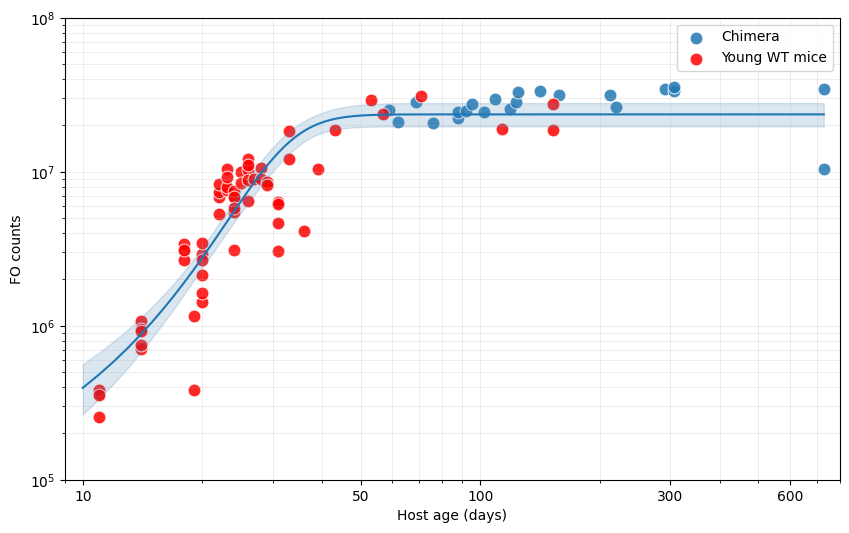

In [28]:

# Plot FM counts

t_ev =np.array(np.arange(10,731,1))
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_FM', alpha=0.85 ,s=85, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='FM', alpha=0.85, s=85, color = 'Red',label='Young WT mice', legend=False)
# plt.plot(np.arange(11, 800, 0.05), P(np.arange(11, 800, 0.05)))
plt.plot(t_ev, np.mean(data_neutral.FO_counts_pred, axis=0))
plt.fill_between(t_ev, np.quantile(data_neutral.FO_counts_pred, 0.025, axis=0), np.quantile(data_neutral.FO_counts_pred, 0.975, axis=0), color = 'steelblue', alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 1e8)
plt.xlim(9, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 50,  100, 300, 600], [10, 50, 100, 300, 600])
plt.xlabel('Host age (days)')
plt.ylabel('FO counts')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


In [29]:
print(np.mean(data_neutral.theta_0))
print(np.mean(data_neutral.nu))
print(np.mean(data_neutral.t0))

16.9714216625
0.207526573875
29.7706641


In [30]:
def P(t):
    theta_0 = np.exp(np.mean(data_neutral.theta_0))
    nu = np.mean(data_neutral.nu)
    t0 = np.mean(data_neutral.t0)
    return theta_0 / (1 + np.exp(-nu * (t - t0)))

# Define delta_func
def delta_func(t, phi, rho_val, P, mz_counts):
    delta = ((phi * P(t)) / mz_counts) + rho_val
    return delta

# Define the ODE function
def ode_function(t, M, phi, rho, P, mz_counts):
    delta = delta_func(t, phi, rho, P, mz_counts)
    dMdt = phi * P(t) - (delta - rho) * M
    return np.array(dMdt)

# Parameters
phi = data_neutral_SHM.stan_variable('phi')
rho = data_neutral_SHM.stan_variable('rho')
mz_counts = data_neutral_SHM.stan_variable('MZ_counts_pred1')[:,0]
# M_stable = data_neutral_SHM.stan_variable('MZ_counts_pred1')

# Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

sol = np.zeros((len(rho), len(t_ev)))
for i in range(len(rho)):
    result = solve_ivp(
        ode_function, [11, 750], M0, t_eval=t_ev,
        args=(phi[i], rho[i], P, mz_counts[i])
    )
    sol[i, :] = result.y[0]

print(sol.shape)

(1200, 739000)


/tmp/ipykernel_818585/4093050606.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


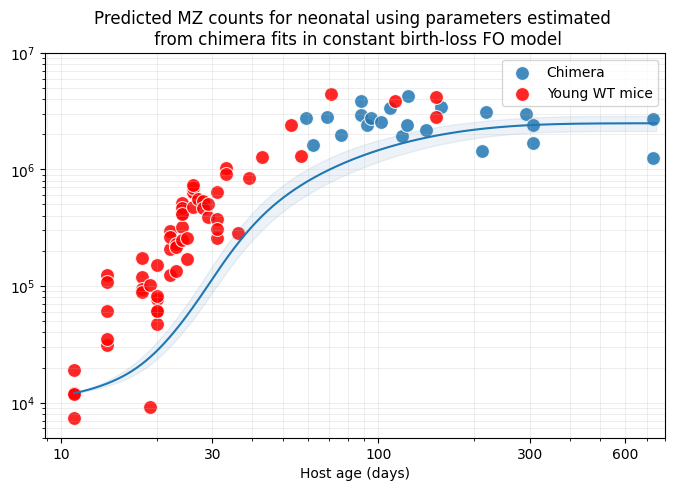

<Figure size 640x480 with 0 Axes>

In [31]:
# Plot the Mz counts
fig = plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
plt.plot(t_ev, np.mean(sol, axis=0))
plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.1)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)')
plt.ylabel('')
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in constant birth-loss FO model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

#save the figure
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny predictions/SHM_FO.png', dpi=300)
plt.show()



In [32]:
def P(t):
    theta_0 = np.exp(np.mean(data_neutral.theta_0))
    nu = np.mean(data_neutral.nu)
    t0 = np.mean(data_neutral.t0)
    return theta_0 / (1 + np.exp(-nu * (t - t0)))

def rho_func(t, rho_var, r_d_val):
    return rho_var / (1 + (t/r_d_val)) 


def delta_func(t, phi_val, rho_val, r_d_val, P,  mz_counts_val):
    delta = ((phi_val * P(t)) / mz_counts_val) + (rho_val / (1 + (t / r_d_val)))
    return delta

# Define the ODE function
def ode_function(t, M, phi_val, rho_val, r_d_val, mz_counts_val, P):
    rho_t = rho_func(t, rho_val, r_d_val)
    delta_t = delta_func(t, phi_val, rho_val, r_d_val, P,  mz_counts_val)
    dMdt = phi_val * P(t) - (delta_t - rho_t) * M
    return np.array(dMdt)

#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

phi = data_neutral_TDD.stan_variable('phi')  #Influx rate
rho_values = data_neutral_TDD.stan_variable('rho')  # Extract 'rho' values from CmdStanMCMC object
r_d_values = data_neutral_TDD.stan_variable('r_d')  # Extract 'r_d' values from CmdStanMCMC object
mz_counts = data_neutral_TDD.stan_variable('MZ_counts_pred1')[:,0]

sol1 = np.zeros((len(rho_values), len(t_ev)))
for i in range(len(rho_values)):
    result = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev,
                       args=(phi[i], rho_values[i], r_d_values[i], mz_counts[i], P))
    sol1[i, :] = result.y[0]


/tmp/ipykernel_818585/3439027697.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


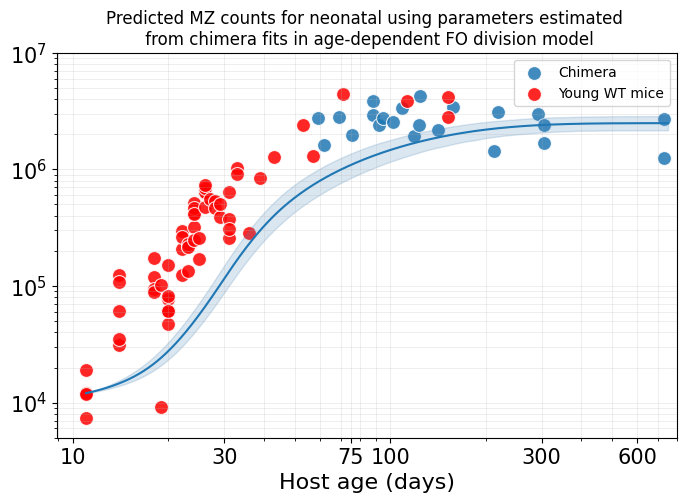

In [33]:
# Plot the Mz counts
fig = plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
# plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
plt.plot(t_ev, np.mean(sol1, axis=0))
plt.fill_between(t_ev, np.quantile(sol1, 0.025, axis=0), np.quantile(sol1, 0.975, axis=0), color = 'steelblue',alpha=0.2)
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=16)
plt.ylabel('')
plt.tick_params(axis='both', labelsize=15)
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in age-dependent FO division model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny predictions/TDM_division_FO.png', dpi=300)
plt.show()

In [34]:
def P(t):
    theta_0 = np.exp(np.mean(data_neutral.theta_0))
    nu = np.mean(data_neutral.nu)
    t0 = np.mean(data_neutral.t0)
    return theta_0 / (1 + np.exp(-nu * (t - t0)))

def phi_func(t, phi, r_d_val):
    return phi * np.exp(-r_d_val * (t-40))


def delta_func(t, phi, rho_val, r_d_val, P, mz_counts):
    delta = (((phi * np.exp(-r_d_val * (t-40))) * P(t)) / mz_counts) + rho_val
    return delta

# Define the ODE function
def ode_function(t, M, phi, rho_val, r_d_val, mz_counts, P):
    phi_t = phi_func(t, phi, r_d_val)
    delta_t = delta_func(t, phi_t, rho_val, r_d_val, P, mz_counts)
    dMdt = phi_t * P(t) - (delta_t - rho_val) * M
    return np.array(dMdt)

#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

phi = data_neutral_TDI.stan_variable('phi')  #Influx rate
rho_val = data_neutral_TDI.stan_variable('rho')  # Extract 'rho' values from CmdStanMCMC object
r_d_val = data_neutral_TDI.stan_variable('r_d')  # Extract 'r_d' values from CmdStanMCMC object
mz_counts = data_neutral_TDI.stan_variable('MZ_counts_pred1')[:,0]

sol2 = np.zeros((len(rho_val), len(t_ev)))
for i in range(len(rho_val)):
    result = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev,
                       args=(phi[i], rho_val[i], r_d_val[i], mz_counts[i], P))
    sol2[i, :] = result.y[0]

IndexError: list index out of range

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
# plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
plt.plot(t_ev, np.mean(sol2, axis=0))
plt.fill_between(t_ev, np.quantile(sol2, 0.025, axis=0), np.quantile(sol2, 0.975, axis=0), color = 'steelblue',alpha=0.2)
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=16)
plt.ylabel('')
plt.tick_params(axis='both', labelsize=15)
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in age-dependent FM influx model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Ontogeny predictions/TDM_influx_FO.png', dpi=300)
plt.show()